In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. Load the dataset
# Make sure 'iris.csv' is in the same directory as this script!
df = pd.read_csv("1) iris.csv")

In [3]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
X = df.drop(columns=["species"])
# 2. Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Use the Elbow Method to find the optimal number of clusters
wcss = []  # Within-Cluster Sum of Squares
cluster_range = range(1, 11)

In [6]:
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


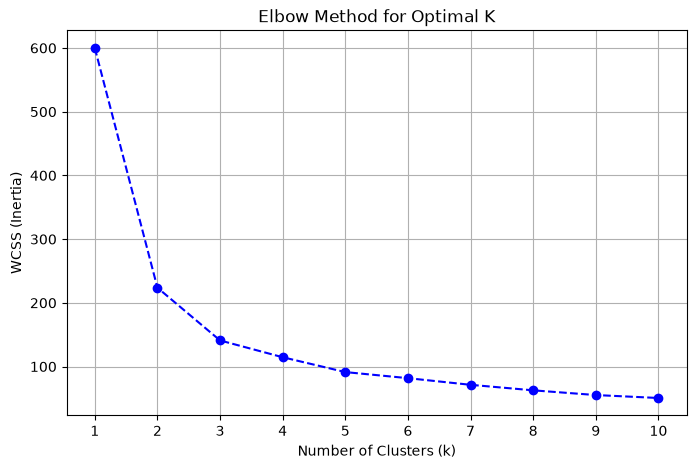

In [7]:
# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker="o", linestyle="--", color="b")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [8]:
# 4. Apply K-Means with the optimal number of clusters
# Based on the Iris dataset, the "elbow" typically clarifies at k = 3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

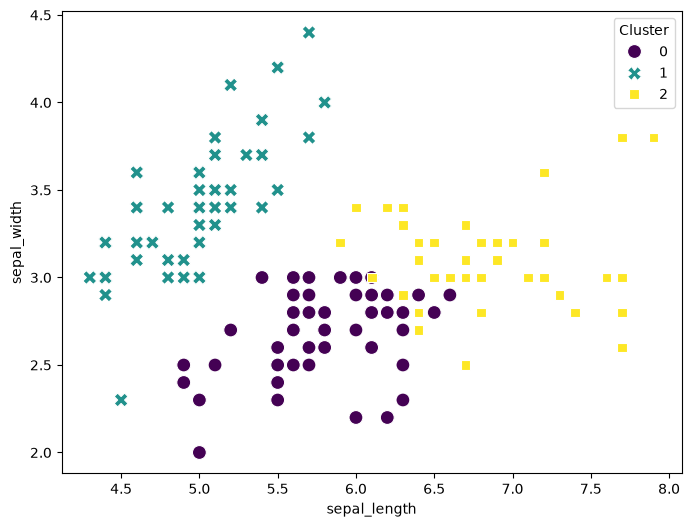

In [9]:
# 5. Visualize the clusters using a 2D Scatter Plot
# We'll plot Sepal Length vs Sepal Width as an example
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["sepal_length"],
    y=df["sepal_width"],
    hue=df["Cluster"],
    palette="viridis",
    s=100,
    style=df["Cluster"],
)

C:\Users\HP\AppData\Local\Temp\ipykernel_7372\2847295192.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Cluster")


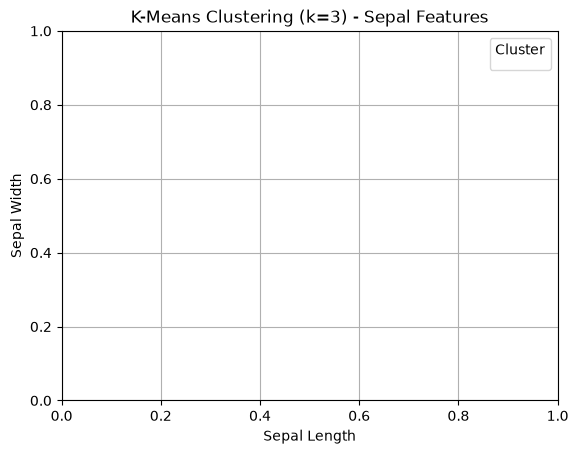

In [10]:
plt.title(f"K-Means Clustering (k={optimal_k}) - Sepal Features")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


<Axes: xlabel='petal_length', ylabel='petal_width'>

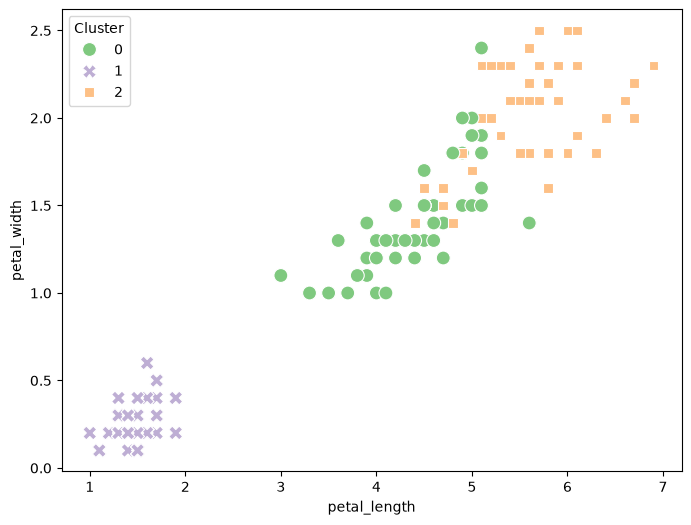

In [11]:
# Optional: Visualize using Petal Features for comparison
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["petal_length"],
    y=df["petal_width"],
    hue=df["Cluster"],
    palette="Accent",
    s=100,
    style=df["Cluster"],
)

C:\Users\HP\AppData\Local\Temp\ipykernel_7372\3960511582.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Cluster")


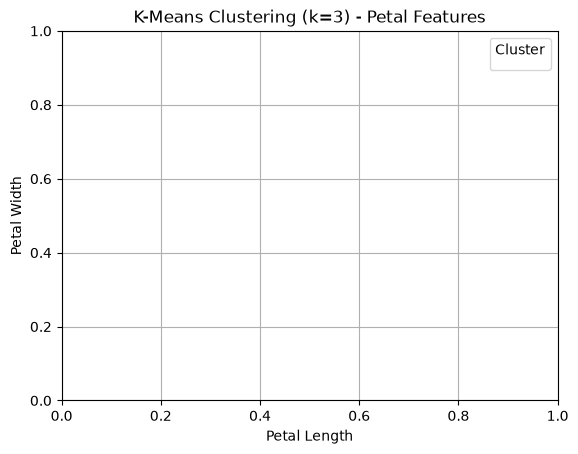

In [12]:

plt.title(f"K-Means Clustering (k={optimal_k}) - Petal Features")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()